# 05. Scale-aware mechanism diagnostics

기존 seed 42/43/44 checkpoint를 사용해 center guidance의 scale별 작동 원인을 분석합니다. **학습이나 optimizer step은 수행하지 않습니다.**

1. Small/Medium/Large별 `AP50, AP55, ..., AP95` IoU threshold curve
2. Hungarian-matched query와 GT의 center error 및 size error 분해
3. Shared encoder memory에서 detection loss와 center loss gradient cosine 측정

Box error는 processor가 사용하는 정규화 `cx, cy, w, h` 좌표에서 계산합니다. 따라서 원본 pixel 크기가 큰 객체일수록 오차가 자동으로 커지는 confound를 줄입니다.


In [1]:
from pathlib import Path
import gc, importlib, json, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm
from transformers import AutoImageProcessor
from transformers.loss.loss_deformable_detr import DeformableDetrHungarianMatcher

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.eval as eval_module
import gt_aux.model as model_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
eval_module = importlib.reload(eval_module)
model_module = importlib.reload(model_module)

ExperimentConfig = config_module.ExperimentConfig
DataBundle = data_module.DataBundle
VOCDataset = data_module.VOCDataset
collate_detection_batch = data_module.collate_detection_batch
parse_voc_record = data_module.parse_voc_record
load_checkpoint = eval_module.load_checkpoint
box_iou = model_module.box_iou
cxcywh_to_xyxy = model_module.cxcywh_to_xyxy


d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 설정

Inference 분석은 validation 100장 전체를 사용합니다. Gradient 분석은 각 scale의 GT가 포함된 batch를 seed별 `GRADIENT_BATCHES`개씩 확보하며, 그래프 통계 단위는 batch가 아니라 seed입니다. cache가 이미 생성된 뒤에는 `RUN_... = False`로 바꾸면 재평가 없이 결과만 다시 그릴 수 있습니다.


In [2]:
RUN_MODE = 'smoke'
SEEDS = [42, 43, 44]
DATA_SEED = 42
EXPERIMENTS = ['baseline', 'shared_detach', 'shared_e2e', 'separate_e2e']
GRADIENT_EXPERIMENTS = ['shared_e2e', 'separate_e2e']
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, NUM_WORKERS = 2, 0
IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 384, 640
FEATURE_LEVEL = 0
IOU_THRESHOLDS = [round(0.50 + 0.05 * i, 2) for i in range(10)]
SCALES = ['small', 'medium', 'large']
GRADIENT_BATCHES = 10
RUN_INFERENCE_DIAGNOSTICS = True
RUN_GRADIENT_DIAGNOSTICS = True

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=EXPERIMENTS, train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    image_min_size=IMAGE_MIN_SIZE, image_max_size=IMAGE_MAX_SIZE,
    feature_level=FEATURE_LEVEL,
)
SEED_TAG = '-'.join(map(str, SEEDS))
OUT = CONFIG.output_dir
IOU_PATH = OUT / f'mechanism_iou_curve_seeds{SEED_TAG}.csv'
BOX_PATH = OUT / f'mechanism_box_errors_seeds{SEED_TAG}.csv'
BOX_SUMMARY_PATH = OUT / f'mechanism_box_error_summary_seeds{SEED_TAG}.csv'
GRADIENT_PATH = OUT / f'mechanism_gradient_conflict_seeds{SEED_TAG}.csv'
IOU_FIGURE_PATH = OUT / f'mechanism_iou_curve_seeds{SEED_TAG}.png'
BOX_FIGURE_PATH = OUT / f'mechanism_box_errors_seeds{SEED_TAG}.png'
GRADIENT_FIGURE_PATH = OUT / f'mechanism_gradient_conflict_seeds{SEED_TAG}.png'
CONFIG.as_dict()


{'root': 'D:\\gt-super',
 'run_mode': 'smoke',
 'checkpoint': 'SenseTime/deformable-detr',
 'train_images': 400,
 'val_images': 100,
 'epochs': 7,
 'batch_size': 2,
 'num_workers': 0,
 'image_size': {'shortest_edge': 384, 'longest_edge': 640},
 'lr': 0.0002,
 'backbone_lr': 2e-05,
 'weight_decay': 0.0001,
 'grad_clip': 0.1,
 'base_aux_weight': 0.5,
 'feature_level': 0,
 'horizontal_flip_p': 0.5,
 'use_amp': True,
 'deterministic': True,
 'save_epoch_checkpoints': False,
 'device': 'cuda',
 'experiments': ['baseline', 'shared_detach', 'shared_e2e', 'separate_e2e'],
 'seed': 42,
 'data_seed': 42}

## 기존 split과 checkpoint 로드

기존 manifest를 읽어 validation subset을 복원합니다. 기존 결과 파일과 checkpoint는 수정하지 않습니다.


In [3]:
MANIFEST_PATH = OUT / 'voc2007_split_manifest.json'
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(MANIFEST_PATH)
manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
if manifest.get('data_seed') != DATA_SEED:
    raise ValueError(f"manifest data_seed={manifest.get('data_seed')} != {DATA_SEED}")

checkpoint_rows = []
for seed in SEEDS:
    for experiment in EXPERIMENTS:
        path = CONFIG.checkpoint_path(experiment, seed)
        checkpoint_rows.append({
            'experiment': experiment, 'seed': seed, 'exists': path.exists(),
            'size_mb': path.stat().st_size / 1024**2 if path.exists() else np.nan,
            'path': str(path),
        })
checkpoint_df = pd.DataFrame(checkpoint_rows)
display(checkpoint_df)
if not checkpoint_df['exists'].all():
    missing = checkpoint_df.loc[~checkpoint_df['exists'], 'path'].tolist()
    raise FileNotFoundError('Missing checkpoints:\n' + '\n'.join(missing))

val_ids = manifest['full_val_ids'][:VAL_IMAGES]
val_records = [parse_voc_record(CONFIG, str(image_id)) for image_id in tqdm(val_ids, desc='VOC val XML')]
try:
    processor = AutoImageProcessor.from_pretrained(CONFIG.checkpoint, local_files_only=True)
except OSError:
    processor = AutoImageProcessor.from_pretrained(CONFIG.checkpoint)
BUNDLE = DataBundle(processor, [], val_records, [], val_records)
collate_fn = lambda batch: collate_detection_batch(batch, BUNDLE.processor, CONFIG)
VAL_LOADER = DataLoader(
    VOCDataset(BUNDLE.val_records, CONFIG, training=False),
    batch_size=CONFIG.batch_size, shuffle=False, num_workers=CONFIG.num_workers,
    pin_memory=torch.cuda.is_available(), collate_fn=collate_fn,
)
print({'val_images': len(val_records), 'val_batches': len(VAL_LOADER), 'device': str(CONFIG.device)})


,experiment,seed,exists,size_mb,path
0,baseline,42,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
1,shared_detach,42,True,461.335190,D:\gt-super\cache\checkpoints\checkpoint_smoke...
2,shared_e2e,42,True,461.330661,D:\gt-super\cache\checkpoints\checkpoint_smoke...
3,separate_e2e,42,True,462.350030,D:\gt-super\cache\checkpoints\checkpoint_smoke...
4,baseline,43,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
5,shared_detach,43,True,461.335190,D:\gt-super\cache\checkpoints\checkpoint_smoke...
6,shared_e2e,43,True,461.330661,D:\gt-super\cache\checkpoints\checkpoint_smoke...
7,separate_e2e,43,True,462.349969,D:\gt-super\cache\checkpoints\checkpoint_smoke...
8,baseline,44,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
9,shared_detach,44,True,461.335190,D:\gt-super\cache\checkpoints\checkpoint_smoke...


VOC val XML: 100%|██████████| 100/100 [00:00<00:00, 2681.21it/s]

{'val_images': 100, 'val_batches': 50, 'device': 'cuda'}


In [4]:
SCALE_TO_AREA_INDEX = {'small': 1, 'medium': 2, 'large': 3}

def object_scale_masks(boxes_xyxy):
    wh = (boxes_xyxy[:, 2:] - boxes_xyxy[:, :2]).clamp(min=0)
    area = wh[:, 0] * wh[:, 1]
    return {
        'small': area < 32**2,
        'medium': (area >= 32**2) & (area < 96**2),
        'large': area >= 96**2,
    }

def valid_mean(values):
    values = values[values >= 0]
    return float(values.mean()) if values.numel() else np.nan

def release_model(model):
    model.close()
    model.cpu()
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 1. IoU threshold curve + center/size error

각 checkpoint를 한 번 inference하여 두 분석을 동시에 수행합니다. Box error의 query-GT 대응은 학습에 쓰인 것과 동일한 Deformable-DETR Hungarian cost(class + L1 + GIoU)로 정합니다.

- `center_error_sq = (cx_hat-cx)^2 + (cy_hat-cy)^2`
- `size_error_l1 = |w_hat-w| + |h_hat-h|`
- `center_error_l2`와 GT 크기로 나눈 `size_error_relative`도 보조 지표로 저장합니다.


In [5]:
@torch.inference_mode()
def inference_diagnostics(experiment, seed):
    model, checkpoint, fingerprint = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
    model.eval()
    detector_config = model.detector.config
    matcher = DeformableDetrHungarianMatcher(
        class_cost=detector_config.class_cost, bbox_cost=detector_config.bbox_cost,
        giou_cost=detector_config.giou_cost,
    )
    metric = MeanAveragePrecision(
        box_format='xyxy', iou_type='bbox', extended_summary=True,
        iou_thresholds=IOU_THRESHOLDS,
    )
    error_rows = []
    try:
        for batch_index, batch in enumerate(tqdm(VAL_LOADER, desc=f'{experiment}/seed{seed}', leave=False)):
            pixel_values = batch['pixel_values'].to(CONFIG.device, non_blocking=True)
            pixel_mask = batch['pixel_mask'].to(CONFIG.device, non_blocking=True)
            labels = [
                {key: value.to(CONFIG.device) for key, value in target.items()}
                for target in batch['labels']
            ]
            result = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=None)
            outputs = result['outputs']

            sizes = torch.stack([target['orig_size'] for target in batch['eval_targets']]).to(CONFIG.device)
            predictions = BUNDLE.processor.post_process_object_detection(
                outputs, threshold=0.0, target_sizes=sizes,
            )
            predictions_cpu = [{key: value.detach().cpu() for key, value in item.items()} for item in predictions]
            targets_cpu = [
                {'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()}
                for target in batch['eval_targets']
            ]
            metric.update(predictions_cpu, targets_cpu)

            match_indices = matcher(
                {'logits': outputs.logits, 'pred_boxes': outputs.pred_boxes}, labels,
            )
            for image_offset, ((source_indices, target_indices), target, eval_target) in enumerate(
                zip(match_indices, labels, batch['eval_targets'])
            ):
                if len(target_indices) == 0:
                    continue
                source_indices = source_indices.to(CONFIG.device)
                target_indices_device = target_indices.to(CONFIG.device)
                predicted_boxes = outputs.pred_boxes[image_offset, source_indices]
                target_boxes = target['boxes'][target_indices_device]
                center_delta = predicted_boxes[:, :2] - target_boxes[:, :2]
                size_delta = (predicted_boxes[:, 2:] - target_boxes[:, 2:]).abs()
                center_error_sq = center_delta.square().sum(dim=-1)
                size_error_l1 = size_delta.sum(dim=-1)
                size_error_relative = (size_delta / target_boxes[:, 2:].clamp(min=1e-6)).sum(dim=-1)
                matched_iou = torch.diag(box_iou(
                    cxcywh_to_xyxy(predicted_boxes), cxcywh_to_xyxy(target_boxes),
                )[0])
                predicted_classes = outputs.logits[image_offset, source_indices].sigmoid().argmax(dim=-1)
                target_classes = target['class_labels'][target_indices_device]
                all_scale_masks = object_scale_masks(eval_target['boxes'])
                scale_masks = {name: mask[target_indices] for name, mask in all_scale_masks.items()}
                image_id = int(eval_target['image_id'])
                for object_offset, target_index in enumerate(target_indices.tolist()):
                    scale = next(name for name, mask in scale_masks.items() if bool(mask[object_offset]))
                    error_rows.append({
                        'experiment': experiment, 'seed': seed, 'scale': scale,
                        'image_id': image_id, 'target_index': target_index,
                        'center_error_sq': float(center_error_sq[object_offset]),
                        'center_error_l2': float(center_error_sq[object_offset].sqrt()),
                        'size_error_l1': float(size_error_l1[object_offset]),
                        'size_error_relative': float(size_error_relative[object_offset]),
                        'matched_iou': float(matched_iou[object_offset]),
                        'label_correct': int(predicted_classes[object_offset] == target_classes[object_offset]),
                    })

        values = metric.compute()
        precision = values['precision']
        curve_rows = []
        for threshold_index, threshold in enumerate(IOU_THRESHOLDS):
            for scale, area_index in SCALE_TO_AREA_INDEX.items():
                curve_rows.append({
                    'experiment': experiment, 'seed': seed, 'scale': scale,
                    'iou_threshold': threshold,
                    'AP': valid_mean(precision[threshold_index, :, :, area_index, -1]),
                    'checkpoint_epoch': checkpoint.get('epoch'), 'fingerprint': fingerprint,
                })
        return curve_rows, error_rows
    finally:
        release_model(model)


In [6]:
if RUN_INFERENCE_DIAGNOSTICS:
    iou_rows, box_rows = [], []
    for seed in SEEDS:
        for experiment in EXPERIMENTS:
            run_iou_rows, run_box_rows = inference_diagnostics(experiment, seed)
            iou_rows.extend(run_iou_rows)
            box_rows.extend(run_box_rows)
    iou_df = pd.DataFrame(iou_rows)
    box_df = pd.DataFrame(box_rows)
    iou_df.to_csv(IOU_PATH, index=False)
    box_df.to_csv(BOX_PATH, index=False)
else:
    iou_df = pd.read_csv(IOU_PATH)
    box_df = pd.read_csv(BOX_PATH)
print('Saved/loaded:', IOU_PATH, BOX_PATH)
print({'iou_rows': len(iou_df), 'matched_box_rows': len(box_df)})


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 16311.28it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

Saved/loaded: D:\gt-super\outputs\detr_gt_auxiliary\mechanism_iou_curve_seeds42-43-44.csv D:\gt-super\outputs\detr_gt_auxiliary\mechanism_box_errors_seeds42-43-44.csv
{'iou_rows': 360, 'matched_box_rows': 3732}


### 1-1. IoU threshold curve

선은 seed 평균, 음영은 seed 표준편차입니다. 아래 crossover 표는 각 방법이 baseline보다 처음 낮아지는 IoU threshold를 보여줍니다.


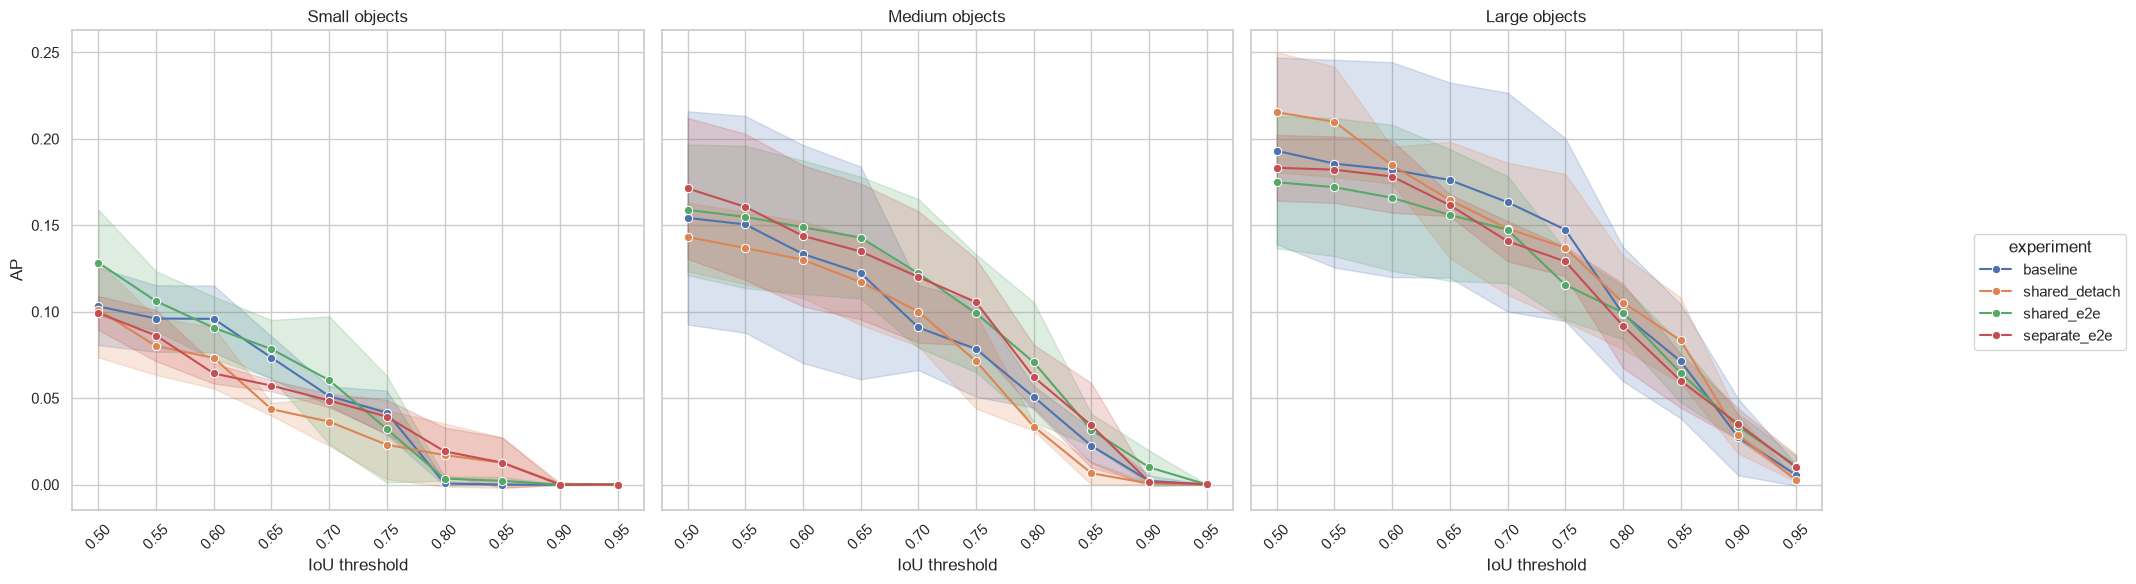

,experiment,scale,first_below_baseline_iou,delta_at_AP50,delta_at_AP75,delta_at_AP95
0,separate_e2e,large,0.50,-0.0098,-0.0184,+0.0044
1,separate_e2e,medium,0.90,+0.0171,+0.0271,+0.0002
2,separate_e2e,small,0.50,-0.0038,-0.0023,+0.0000
3,shared_detach,large,0.65,+0.0223,-0.0105,-0.0030
4,shared_detach,medium,0.50,-0.0111,-0.0070,+0.0000
5,shared_detach,small,0.50,-0.0020,-0.0186,+0.0000
6,shared_e2e,large,0.50,-0.0182,-0.0319,+0.0053
7,shared_e2e,medium,nan,+0.0047,+0.0207,+0.0000
8,shared_e2e,small,0.60,+0.0253,-0.0095,+0.0000


Saved: D:\gt-super\outputs\detr_gt_auxiliary\mechanism_iou_curve_seeds42-43-44.png


In [7]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
for axis, scale in zip(axes, SCALES):
    sns.lineplot(
        data=iou_df.query('scale == @scale'), x='iou_threshold', y='AP',
        hue='experiment', estimator='mean', errorbar='sd', marker='o', ax=axis,
    )
    axis.set_title(f'{scale.capitalize()} objects')
    axis.set_xlabel('IoU threshold')
    axis.set_ylabel('AP' if axis is axes[0] else '')
    axis.set_xticks(IOU_THRESHOLDS)
    axis.tick_params(axis='x', rotation=45)
handles, labels = axes[0].get_legend_handles_labels()
for axis in axes:
    if axis.get_legend() is not None:
        axis.get_legend().remove()
fig.legend(handles, labels, title='experiment', loc='center right', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.savefig(IOU_FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()

mean_curve = iou_df.groupby(['experiment', 'scale', 'iou_threshold'], as_index=False)['AP'].mean()
baseline_curve = (
    mean_curve.query("experiment == 'baseline'")
    [['scale', 'iou_threshold', 'AP']].rename(columns={'AP': 'baseline_AP'})
)
curve_delta = mean_curve.merge(baseline_curve, on=['scale', 'iou_threshold'])
curve_delta['delta_AP'] = curve_delta['AP'] - curve_delta['baseline_AP']
crossover_rows = []
for (experiment, scale), group in curve_delta.query("experiment != 'baseline'").groupby(['experiment', 'scale']):
    negative = group.sort_values('iou_threshold').query('delta_AP < 0')
    crossover_rows.append({
        'experiment': experiment, 'scale': scale,
        'first_below_baseline_iou': negative['iou_threshold'].iloc[0] if not negative.empty else np.nan,
        'delta_at_AP50': float(group.query('iou_threshold == 0.50')['delta_AP'].iloc[0]),
        'delta_at_AP75': float(group.query('iou_threshold == 0.75')['delta_AP'].iloc[0]),
        'delta_at_AP95': float(group.query('iou_threshold == 0.95')['delta_AP'].iloc[0]),
    })
crossover_df = pd.DataFrame(crossover_rows)
display(crossover_df.style.format({
    'first_below_baseline_iou': '{:.2f}', 'delta_at_AP50': '{:+.4f}',
    'delta_at_AP75': '{:+.4f}', 'delta_at_AP95': '{:+.4f}',
}))
print('Saved:', IOU_FIGURE_PATH)


### 1-2. Center error vs size error

먼저 객체별 값을 seed·experiment·scale 단위로 평균낸 뒤, 그래프에서 세 seed의 평균과 표준편차를 표시합니다. 즉 객체 수가 많은 seed가 통계를 지배하지 않습니다.


,experiment,seed,scale,center_error_sq_mean,center_error_sq_count,center_error_l2_mean,center_error_l2_count,size_error_l1_mean,size_error_l1_count,size_error_relative_mean,size_error_relative_count,matched_iou_mean,matched_iou_count,label_correct_mean,label_correct_count
0,baseline,42,large,0.001133,190,0.024763,190,0.050450,190,0.129775,190,0.828243,190,0.526316,190
1,baseline,42,medium,0.001488,83,0.025862,83,0.047877,83,0.353164,83,0.617612,83,0.542169,83
2,baseline,42,small,0.000904,38,0.021650,38,0.051200,38,1.288104,38,0.411917,38,0.315789,38
3,baseline,43,large,0.001086,190,0.025487,190,0.050088,190,0.124274,190,0.832554,190,0.515789,190
4,baseline,43,medium,0.000916,83,0.021683,83,0.049007,83,0.405687,83,0.632032,83,0.421687,83
5,baseline,43,small,0.001389,38,0.023300,38,0.044310,38,0.964426,38,0.445756,38,0.342105,38
6,baseline,44,large,0.001147,190,0.024896,190,0.053893,190,0.138016,190,0.824915,190,0.489474,190
7,baseline,44,medium,0.001718,83,0.024945,83,0.049215,83,0.401393,83,0.614381,83,0.493976,83
8,baseline,44,small,0.001285,38,0.026187,38,0.061216,38,1.349173,38,0.366686,38,0.315789,38
9,separate_e2e,42,large,0.001162,190,0.024517,190,0.051264,190,0.134260,190,0.831290,190,0.521053,190


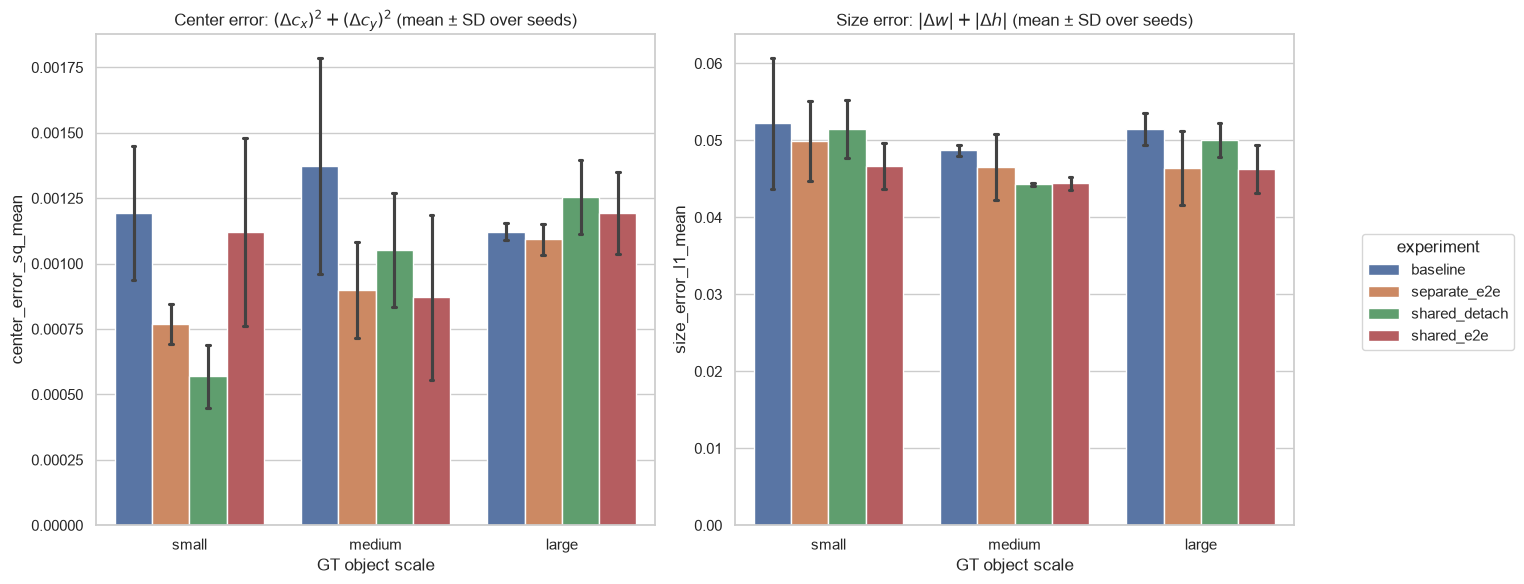

Saved: D:\gt-super\outputs\detr_gt_auxiliary\mechanism_box_error_summary_seeds42-43-44.csv D:\gt-super\outputs\detr_gt_auxiliary\mechanism_box_errors_seeds42-43-44.png


In [8]:
BOX_METRICS = [
    'center_error_sq', 'center_error_l2', 'size_error_l1',
    'size_error_relative', 'matched_iou', 'label_correct',
]
box_seed_df = (
    box_df.groupby(['experiment', 'seed', 'scale'])[BOX_METRICS]
    .agg(['mean', 'count']).reset_index()
)
box_seed_df.columns = [
    '_'.join(part for part in column if part).rstrip('_') if isinstance(column, tuple) else column
    for column in box_seed_df.columns
]
box_seed_df.to_csv(BOX_SUMMARY_PATH, index=False)
display(box_seed_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, metric, title in [
    (axes[0], 'center_error_sq_mean', r'Center error: $(\Delta c_x)^2 + (\Delta c_y)^2$'),
    (axes[1], 'size_error_l1_mean', r'Size error: $|\Delta w| + |\Delta h|$'),
]:
    sns.barplot(
        data=box_seed_df, x='scale', y=metric, hue='experiment',
        order=SCALES, estimator='mean', errorbar='sd', capsize=0.08, ax=axis,
    )
    axis.set_title(title + ' (mean ± SD over seeds)')
    axis.set_xlabel('GT object scale')
handles, labels = axes[0].get_legend_handles_labels()
for axis in axes:
    if axis.get_legend() is not None:
        axis.get_legend().remove()
fig.legend(handles, labels, title='experiment', loc='center right', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.savefig(BOX_FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()

baseline_errors = (
    box_seed_df.query("experiment == 'baseline'")
    [['seed', 'scale', 'center_error_sq_mean', 'size_error_l1_mean']]
    .rename(columns={
        'center_error_sq_mean': 'baseline_center_error_sq',
        'size_error_l1_mean': 'baseline_size_error_l1',
    })
)
error_delta_df = box_seed_df.merge(baseline_errors, on=['seed', 'scale'])
error_delta_df['delta_center_error'] = error_delta_df['center_error_sq_mean'] - error_delta_df['baseline_center_error_sq']
error_delta_df['delta_size_error'] = error_delta_df['size_error_l1_mean'] - error_delta_df['baseline_size_error_l1']
error_delta_summary = (
    error_delta_df.groupby(['experiment', 'scale'])[['delta_center_error', 'delta_size_error']]
    .agg(['mean', 'std'])
)
display(error_delta_summary.style.format('{:+.6f}'))
print('Saved:', BOX_SUMMARY_PATH, BOX_FIGURE_PATH)


## 2. Scale별 gradient conflict

각 scale의 GT만 남겨 동일한 forward graph에서 다음 gradient를 구합니다.

- `g_total`: 전체 main detection loss의 encoder-memory gradient
- `g_loc`: `5 × main L1 + 2 × main GIoU`의 encoder-memory gradient
- `g_center`: center auxiliary loss의 encoder-memory gradient

`cosine_*_support`는 center loss가 실제로 gradient를 보내는 spatial memory 위치에서만 계산한 주 지표이고, `cosine_*_full`은 전체 encoder memory에서 계산한 보조 지표입니다. `shared_detach`는 설계상 center gradient가 encoder에 연결되지 않고 baseline은 center loss가 없으므로, gradient 비교는 `shared_e2e`와 `separate_e2e`에 대해 수행합니다.


In [9]:
OBJECT_LABEL_KEYS = {'class_labels', 'boxes', 'area', 'iscrowd'}

def filtered_labels_for_scale(batch, scale):
    filtered = []
    total_objects = 0
    for label, eval_target in zip(batch['labels'], batch['eval_targets']):
        mask = object_scale_masks(eval_target['boxes'])[scale]
        total_objects += int(mask.sum())
        target = {}
        for key, value in label.items():
            value = value.to(CONFIG.device)
            if key in OBJECT_LABEL_KEYS:
                value = value[mask.to(CONFIG.device)]
            target[key] = value
        filtered.append(target)
    return filtered, total_objects

def gradient_vector_stats(det_grad, center_grad, support_only):
    if det_grad is None or center_grad is None:
        return np.nan, np.nan, np.nan, np.nan
    if support_only:
        support = center_grad.detach().float().norm(dim=-1) > 0
        if not support.any():
            return np.nan, np.nan, np.nan, 0
        det_vector = det_grad[support].detach().flatten().float()
        center_vector = center_grad[support].detach().flatten().float()
        support_count = int(support.sum())
    else:
        det_vector = det_grad.detach().flatten().float()
        center_vector = center_grad.detach().flatten().float()
        support_count = int(center_grad.detach().float().norm(dim=-1).gt(0).sum())
    det_norm = det_vector.norm()
    center_norm = center_vector.norm()
    if det_norm <= 0 or center_norm <= 0:
        return np.nan, float(det_norm), float(center_norm), support_count
    cosine = F.cosine_similarity(det_vector, center_vector, dim=0)
    return float(cosine), float(det_norm), float(center_norm), support_count


In [10]:
def gradient_diagnostics(experiment, seed):
    model, checkpoint, fingerprint = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
    # Wrapper training=True activates auxiliary loss; children stay in eval mode to disable dropout.
    model.train()
    model.detector.eval()
    model.adapter.eval()
    rows = []
    scale_batch_counts = {scale: 0 for scale in SCALES}
    try:
        for batch_index, batch in enumerate(tqdm(VAL_LOADER, desc=f'grad {experiment}/seed{seed}', leave=False)):
            if all(count >= GRADIENT_BATCHES for count in scale_batch_counts.values()):
                break
            pixel_values = batch['pixel_values'].to(CONFIG.device, non_blocking=True)
            pixel_mask = batch['pixel_mask'].to(CONFIG.device, non_blocking=True)
            for scale in SCALES:
                if scale_batch_counts[scale] >= GRADIENT_BATCHES:
                    continue
                labels, object_count = filtered_labels_for_scale(batch, scale)
                if object_count == 0:
                    continue
                result = model(
                    pixel_values=pixel_values, pixel_mask=pixel_mask,
                    labels=labels, aux_weight=1.0,
                )
                if not result['aux_executed'] or result['aux_used'] == 0:
                    continue
                memory = model._encoder_cache['memory']
                loss_dict = result['outputs'].loss_dict
                localization_loss = (
                    model.detector.config.bbox_loss_coefficient * loss_dict['loss_bbox']
                    + model.detector.config.giou_loss_coefficient * loss_dict['loss_giou']
                )
                total_grad = torch.autograd.grad(
                    result['main_loss'], memory, retain_graph=True, allow_unused=True,
                )[0]
                loc_grad = torch.autograd.grad(
                    localization_loss, memory, retain_graph=True, allow_unused=True,
                )[0]
                center_grad = torch.autograd.grad(
                    result['aux_loss'], memory, retain_graph=False, allow_unused=True,
                )[0]
                total_full = gradient_vector_stats(total_grad, center_grad, support_only=False)
                total_support = gradient_vector_stats(total_grad, center_grad, support_only=True)
                loc_full = gradient_vector_stats(loc_grad, center_grad, support_only=False)
                loc_support = gradient_vector_stats(loc_grad, center_grad, support_only=True)
                rows.append({
                    'experiment': experiment, 'seed': seed, 'scale': scale,
                    'batch_index': batch_index, 'object_count': object_count,
                    'aux_used': result['aux_used'], 'aux_collisions': result['aux_collisions'],
                    'cosine_total_full': total_full[0], 'cosine_total_support': total_support[0],
                    'cosine_loc_full': loc_full[0], 'cosine_loc_support': loc_support[0],
                    'main_total_grad_norm': total_full[1], 'main_loc_grad_norm': loc_full[1],
                    'center_grad_norm': loc_full[2], 'center_support_positions': loc_full[3],
                    'checkpoint_epoch': checkpoint.get('epoch'), 'fingerprint': fingerprint,
                })
                scale_batch_counts[scale] += 1
                del result, memory, total_grad, loc_grad, center_grad
        return rows
    finally:
        release_model(model)


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 20180.59it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

Saved/loaded: D:\gt-super\outputs\detr_gt_auxiliary\mechanism_gradient_conflict_seeds42-43-44.csv {'rows': 180}


,experiment,seed,scale,cosine_total_full,cosine_total_support,cosine_loc_full,cosine_loc_support
0,separate_e2e,42,large,0.011544,0.130479,0.011927,0.134710
1,separate_e2e,42,medium,0.040924,0.207920,0.041315,0.212076
2,separate_e2e,42,small,0.031237,0.111249,0.031178,0.109600
3,separate_e2e,43,large,0.005275,0.071941,0.004947,0.066529
4,separate_e2e,43,medium,0.029447,0.181901,0.029077,0.177639
5,separate_e2e,43,small,0.041019,0.143884,0.040163,0.141288
6,separate_e2e,44,large,0.005814,0.034425,0.006106,0.031789
7,separate_e2e,44,medium,0.069550,0.236428,0.071845,0.244186
8,separate_e2e,44,small,0.012773,0.050643,0.011875,0.046882
9,shared_e2e,42,large,0.027080,0.147913,0.027302,0.147161


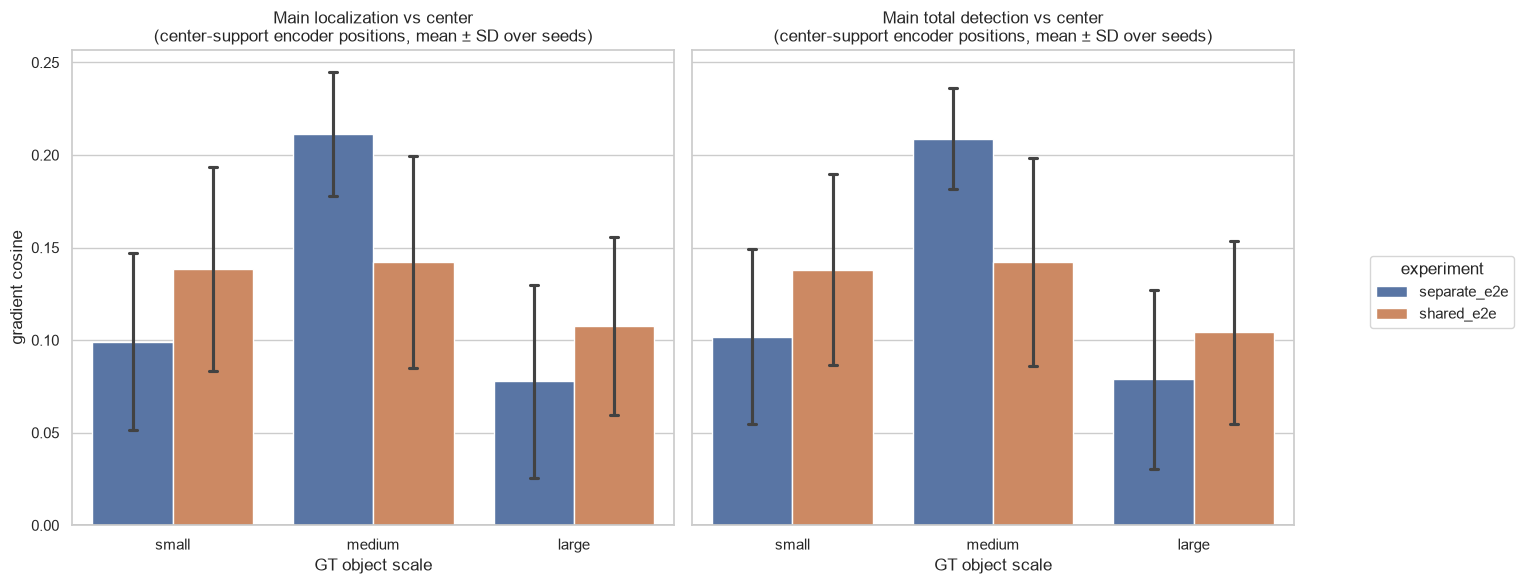

Saved: D:\gt-super\outputs\detr_gt_auxiliary\mechanism_gradient_conflict_seeds42-43-44.png


In [11]:
if RUN_GRADIENT_DIAGNOSTICS:
    gradient_rows = []
    for seed in SEEDS:
        for experiment in GRADIENT_EXPERIMENTS:
            gradient_rows.extend(gradient_diagnostics(experiment, seed))
    gradient_df = pd.DataFrame(gradient_rows)
    gradient_df.to_csv(GRADIENT_PATH, index=False)
else:
    gradient_df = pd.read_csv(GRADIENT_PATH)
print('Saved/loaded:', GRADIENT_PATH, {'rows': len(gradient_df)})

GRADIENT_METRICS = [
    'cosine_total_full', 'cosine_total_support',
    'cosine_loc_full', 'cosine_loc_support',
]
gradient_seed_df = (
    gradient_df.groupby(['experiment', 'seed', 'scale'], as_index=False)[GRADIENT_METRICS]
    .mean()
)
display(gradient_seed_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for axis, metric, title in [
    (axes[0], 'cosine_loc_support', 'Main localization vs center'),
    (axes[1], 'cosine_total_support', 'Main total detection vs center'),
]:
    sns.barplot(
        data=gradient_seed_df, x='scale', y=metric, hue='experiment',
        order=SCALES, estimator='mean', errorbar='sd', capsize=0.08, ax=axis,
    )
    axis.axhline(0, color='black', linewidth=1)
    axis.set_title(title + '\n(center-support encoder positions, mean ± SD over seeds)')
    axis.set_xlabel('GT object scale')
    axis.set_ylabel('gradient cosine' if axis is axes[0] else '')
handles, labels = axes[0].get_legend_handles_labels()
for axis in axes:
    if axis.get_legend() is not None:
        axis.get_legend().remove()
fig.legend(handles, labels, title='experiment', loc='center right', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.savefig(GRADIENT_FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()
display(
    gradient_seed_df.groupby(['experiment', 'scale'])[GRADIENT_METRICS]
    .agg(['mean', 'std']).style.format('{:+.4f}')
)
print('Saved:', GRADIENT_FIGURE_PATH)


## 3. 가설 체크 요약

아래 셀은 shared-E2E의 baseline 대비 center/size error 방향과 scale별 gradient cosine을 한 표에 모읍니다. 세 seed뿐인 진단 결과이므로 통계적 확증이 아니라 다음 구조 변경의 근거로 해석합니다.


In [12]:
shared_error = (
    error_delta_df.query("experiment == 'shared_e2e'")
    .groupby('scale')[['delta_center_error', 'delta_size_error']].agg(['mean', 'std'])
)
shared_gradient = (
    gradient_seed_df.query("experiment == 'shared_e2e'")
    .groupby('scale')[['cosine_loc_support', 'cosine_total_support']].agg(['mean', 'std'])
)
display(shared_error.style.format('{:+.6f}'))
display(shared_gradient.style.format('{:+.4f}'))

large_error = shared_error.loc['large']
center_down_size_up = (
    large_error[('delta_center_error', 'mean')] < 0
    and large_error[('delta_size_error', 'mean')] > 0
)
shared_gradient_means = shared_gradient.xs('mean', axis=1, level=1)
scale_conflict_pattern = (
    shared_gradient_means.loc['small', 'cosine_loc_support'] > 0
    and shared_gradient_means.loc['medium', 'cosine_loc_support'] > 0
    and shared_gradient_means.loc['large', 'cosine_loc_support'] <= 0
)
print({
    'shared_e2e_large_center_down_and_size_up': bool(center_down_size_up),
    'shared_e2e_positive_small_medium_nonpositive_large_gradient': bool(scale_conflict_pattern),
})


{'shared_e2e_large_center_down_and_size_up': False, 'shared_e2e_positive_small_medium_nonpositive_large_gradient': False}
